In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import Feature_Engineering as FE
import matplotlib.pyplot as plt

In [13]:
data = FE.data
data_reg = data[(data['INGRESO'] == 1)]
y_reg = data_reg['logP47T']
excluir_cols = {'logP47T', 'Q','INGRESO', 'CODUSU', 'P47T', 'P21', 'T_VI', 'V12_M', 'V2_M', 'V3_M', 'V5_M', 'TOT_P12', 'PP08D1', 
                'logP21', 'logT_VI', 'logV12_M', 'logV2_M', 'logV3_M', 'logV5_M', 'logTOT_P12', 'logPP08D1','ANO4','TRIMESTRE', 'INGRESO_NLB','INGRESO_JUB','INGRESO_SBS'}
X_reg = data_reg.drop(columns=excluir_cols)
print(X_reg.head(20))

   AGLOMERADO V01 H05 H06 H07 H08  H09 H10 H11 H12  H16  H15 PROP H14 H13  \
0          23   1   0   3   1   1  1.0   1   1   1  4.0  1.0  3.0   2   1   
1          18   2   1   9   1   1  1.0   1   1   1  3.0  2.0  1.0   1   1   
4          18   2   1   9   1   1  1.0   1   1   1  3.0  2.0  1.0   1   1   
5          33   1   1   3   1   1  1.0   1   1   1  4.0  2.0  3.0   1   1   
6          33   1   1   3   1   1  1.0   1   1   1  4.0  2.0  3.0   1   1   
8          33   1   1   3   1   1  1.0   1   1   1  4.0  2.0  3.0   1   1   
9          33   1   1   3   1   1  1.0   1   1   1  4.0  2.0  3.0   1   1   
12         17   1   1   4   1   1  1.0   1   1   1  3.0  2.0  1.0   1   1   
13         32   1   1   2   1   1  1.0   1   1   1  3.0  2.0  0.0   0   1   
16          4   1   0   1   1   1  1.0   1   1   2  2.0  2.0  1.0   2   1   
17          4   1   0   1   1   1  1.0   1   1   2  2.0  2.0  1.0   2   1   
18         93   1   1   1   1   1  1.0   1   1   1  2.0  1.0  1.0   1   1   

In [14]:
X_train_test, X_val, y_train_test, y_val = train_test_split(X_reg, y_reg, test_size=0.10, random_state=42) #Separo 10% para validacion
X_train, X_test, y_train, y_test = train_test_split(X_train_test, y_train_test, test_size=2/9, random_state=42) #Separo 20% total para test, 70% Train
print(X_test[(data["PROP"].notna())].shape)
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

(65682, 53)


C:\Users\uzvp\AppData\Local\Temp\ipykernel_44840\2248252272.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(X_test[(data["PROP"].notna())].shape)


In [ ]:
# Grilla inicial hiperparámetros
param_grids_base = {
    "LinearRegression": {
        "reg__fit_intercept": [True]
    },
    "Ridge": {
        "reg__alpha": [2, 5, 10],
        "reg__fit_intercept": [True]
    },
    "Lasso": {
        "reg__alpha": [0.005,0.0025,0.0075],
        "reg__fit_intercept": [True]
    },
    "HistGradientBoostingRegressor": {
        "reg__max_iter": [100,200],
        "reg__learning_rate": [0.25, 0.1, 0.05],
        "reg__max_leaf_nodes": [200,400],
        "reg__min_samples_leaf": [15,30],
        "reg__l2_regularization": [0]
    }
}

In [ ]:
# Preprocesadores

preproc_scaled = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop = 'first'), cat_cols)
], remainder='drop')

preproc_unscaled = ColumnTransformer([
    ('num', 'passthrough', num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop = 'first'), cat_cols)
], remainder='drop')

In [6]:
#Pipelines

pipelines = {
        "LinearRegression": Pipeline([('preproc', preproc_unscaled), ('reg', LinearRegression())]),
        "Ridge": Pipeline([('preproc', preproc_scaled), ('reg', Ridge())]),
        "Lasso": Pipeline([('preproc', preproc_scaled), ('reg', Lasso(max_iter=200))]),
        "HistGradientBoostingRegressor": Pipeline([('preproc', preproc_unscaled), ('reg', HistGradientBoostingRegressor(random_state=42))])
    }

In [ ]:
best_model = None
best_r2 = -np.inf
best_params = None

best_lr = None
best_lr_params = None
best_lr_r2 = -np.inf

best_ridge = None
best_ridge_params = None
best_ridge_r2 = -np.inf

best_lasso = None
best_lasso_params = None
best_lasso_r2 = -np.inf

best_hgb = None
best_hgb_params = None
best_hgb_r2 = -np.inf

for name, pipe in pipelines.items():
    print(f"\n=== Evaluando modelo: {name} ===")
    grid = GridSearchCV(
        pipe,
        param_grids_base[name],
        cv=5,
        refit='r2',
        scoring=['r2', 'neg_mean_squared_error', 'neg_mean_absolute_error'],
        n_jobs=-1,
        verbose=0
    )
    grid.fit(X_train, y_train)

    best = grid.best_estimator_

    y_pred = best.predict(X_test)

    test_mse = mean_squared_error(y_test, y_pred)
    test_r2 = r2_score(y_test, y_pred)
    test_mae = mean_absolute_error(y_test, y_pred)

    # Guardar informacion de la mejor configuracion de cada modelo. Como en principio no sé cual es mejor entre los regresores lineales (estándar, Ridge, Lasso) ó el HistGradientBoosting, 
    # mantendré un registro de todos. Luego, solo usaré para graficar el mejor regresor lineal (incluyendo modelos con penalizacion como Ridge y Lasso), y el mejor HistGradientBoosting.

    if name == "LinearRegression":
        if test_r2 > best_lr_r2:
            best_lr = best
            best_lr_params = grid.best_params_
            best_lr_r2 = test_r2
    if name == "Ridge":
        if test_r2 > best_ridge_r2:
            best_ridge = best
            best_ridge_params = grid.best_params_
            best_ridge_r2 = test_r2
    if name == "Lasso":
        if test_r2 > best_lasso_r2:
            best_lasso = best
            best_lasso_params = grid.best_params_
            best_lasso_r2 = test_r2
    if name == "HistGradientBoostingRegressor":
        if test_r2 > best_hgb_r2:
            best_hgb = best
            best_hgb_params = grid.best_params_
            best_hgb_r2 = test_r2

    print("Best params:", grid.best_params_)
    print("Best CV score:", grid.best_score_)
    print("Regression metrics (test):")
    print("MSE:", test_mse)
    print("MAE:", test_mae)
    print("R2:", test_r2)

    if test_r2 > best_r2:
        best_r2 = test_r2
        best_model = best
        best_params = grid.best_params_

print("\n=== Mejor modelo global ===")
print("Mejor modelo:", best_model)
print("Mejores hiperparámetros:", best_params)
print("Mejor R2 en test:", best_r2)



=== Evaluando modelo: LinearRegression ===
Best params: {'reg__fit_intercept': False}
Best CV score: 0.5378532545895156
Regression metrics (test):
MSE: 0.06519544505050022
R2: 0.5442626315902053

=== Evaluando modelo: Ridge ===
Best params: {'reg__alpha': 5, 'reg__fit_intercept': True}
Best CV score: 0.5378606156027177
Regression metrics (test):
MSE: 0.06519684269134945
R2: 0.5442528616260287

=== Evaluando modelo: Lasso ===
Best params: {'reg__alpha': 0.0025, 'reg__fit_intercept': True}
Best CV score: 0.5169593848105813
Regression metrics (test):
MSE: 0.06823283570725144
R2: 0.523030282862958

=== Evaluando modelo: HistGradientBoostingRegressor ===
Best params: {'reg__l2_regularization': 0, 'reg__learning_rate': 0.1, 'reg__max_iter': 200, 'reg__max_leaf_nodes': 400, 'reg__min_samples_leaf': 15}
Best CV score: 0.6371007670015392
Regression metrics (test):
MSE: 0.05076599127843157
R2: 0.6451292072317945

=== Mejor modelo global ===
Mejor modelo: Pipeline(steps=[('preproc',
            

In [ ]:
#Ahora quiero usar este mejor modelo global para, dados los datos de X_val, predecir y_val y registrar MSE y R2

y_val_pred = best_model.predict(X_val)
y_val_mse = mean_squared_error(y_val, y_val_pred)
y_val_mae = mean_absolute_error(y_val, y_val_pred)
y_val_r2 = r2_score(y_val, y_val_pred)


print("MSE en validación:", y_val_mse)
print("MAE en validación:", y_val_mae)
print("R2 en validación:", y_val_r2)


MSE en validación: 0.05109761789996068
R2 en validación: 0.6425289218668218


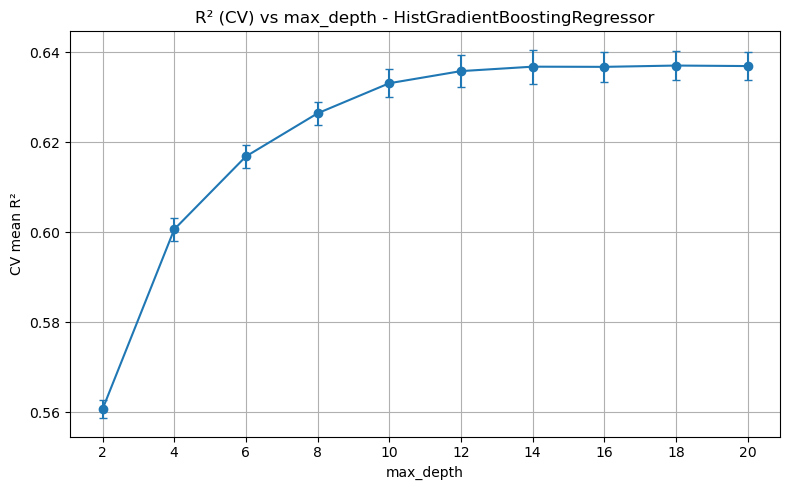

Best max_depth: 18
Best CV R²: 0.6370572512855007


In [10]:
# Grafico R² por max_depth (cada 1 unidad)

pipe_hgb = pipelines['HistGradientBoostingRegressor']

# grid solo sobre max_depth (otros hiperparámetros fijos)
param_grid_hgb = {
    'reg__max_depth': list(range(2, 22, 2)),
    'reg__max_iter': [200],
    'reg__learning_rate': [0.1],
    'reg__max_leaf_nodes': [400],
    'reg__min_samples_leaf': [15],
    'reg__l2_regularization': [0]
}

gs_hgb = GridSearchCV(
    pipe_hgb,
    param_grid_hgb,
    cv=5,
    scoring='r2',      # queremos R^2
    n_jobs=-1,
    verbose=0,
    return_train_score=False
)

gs_hgb.fit(X_train, y_train)

# extraer resultados y ordenar por max_depth
cv_results = gs_hgb.cv_results_
depths = np.array([int(d) for d in cv_results['param_reg__max_depth']])
means = np.array(cv_results['mean_test_score'])
stds = np.array(cv_results['std_test_score'])

# ordenar por depths
order = np.argsort(depths)
depths = depths[order]
means = means[order]
stds = stds[order]

plt.figure(figsize=(8,5))
plt.errorbar(depths, means, yerr=stds, marker='o', capsize=3)
plt.xlabel('max_depth')
plt.ylabel('CV mean R²')
plt.title('R² (CV) vs max_depth - HistGradientBoostingRegressor')
plt.grid(True)
plt.xticks(depths)
plt.tight_layout()
plt.savefig("HGB_R2_vs_max_depth.png")
plt.show()

print("Best max_depth:", gs_hgb.best_params_['reg__max_depth'])
print("Best CV R²:", gs_hgb.best_score_)

Iteraciones muestreadas: 20 (cada 10)
Mejor iteración (entre muestreadas) por R² test: 200 (R²=0.6409)


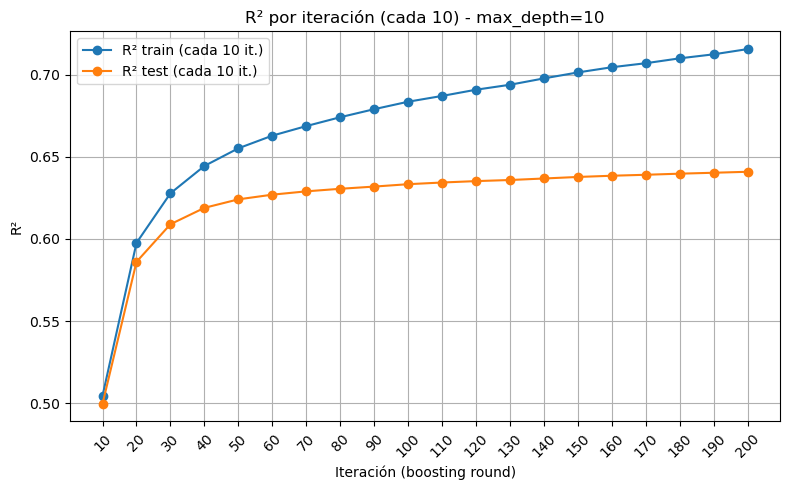

In [ ]:
max_iter_total = 201
sample_every = 10

reg_params = dict(
    max_depth=10,
    learning_rate=0.1,
    max_leaf_nodes=400,
    min_samples_leaf=15,
    l2_regularization=0.0,
    max_iter=max_iter_total,
    random_state=42
)

preproc = preproc_unscaled

X_train_tr = preproc.fit_transform(X_train)
X_test_tr  = preproc.transform(X_test)

reg = HistGradientBoostingRegressor(**reg_params)
reg.fit(X_train_tr, y_train)

# R² por iteración
sample_iters, sample_train, sample_test = [], [], []
best_it = None
best_r2 = -np.inf

for it, (y_pred_tr, y_pred_te) in enumerate(
    zip(reg.staged_predict(X_train_tr), reg.staged_predict(X_test_tr)),
    start=1
):
    if it % sample_every != 0:
        continue

    r2_tr = r2_score(y_train, y_pred_tr)
    r2_te = r2_score(y_test, y_pred_te)

    sample_iters.append(it)
    sample_train.append(r2_tr)
    sample_test.append(r2_te)

    if r2_te > best_r2:
        best_r2 = r2_te
        best_it = it

print(f"Iteraciones muestreadas: {len(sample_iters)} (cada {sample_every})")
print(f"Mejor iteración (entre muestreadas) por R² test: {best_it} (R²={best_r2:.4f})")

# Plot
plt.figure(figsize=(8, 5))
plt.plot(sample_iters, sample_train, marker="o", label=f"R² train (cada {sample_every} it.)")
plt.plot(sample_iters, sample_test, marker="o", label=f"R² test (cada {sample_every} it.)")
plt.xlabel("Iteración (boosting round)")
plt.ylabel("R²")
plt.title(f"R² por iteración (cada {sample_every}) - max_depth={reg_params['max_depth']}")
plt.grid(True)
plt.legend()
plt.xticks(sample_iters, rotation=45)
plt.tight_layout()
plt.savefig("HGB_R2_por_iteracion.png")
plt.show()
